In [1]:
import matplotlib.pyplot as plt
import control as ct 
import numpy as np

In [2]:
def plottingFunction(xAxisVector, 
                     yAxisVector, 
                     titleString, 
                     stringXAxis, 
                     stringYAxis, 
                     stringFileName):
    
    plt.figure(figsize=(8,6))
    plt.plot(xAxisVector, yAxisVector, color='blue', linewidth=4)
    plt.title(titleString, fontsize=14)
    plt.xlabel(stringXAxis, fontsize=14)
    plt.ylabel(stringYAxis, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.grid(visible=True)
    plt.savefig(stringFileName, dpi=600)
    plt.show()

In [3]:
# Define the system parameters
m1 = 2
m2 = 3
k1 = 100
k2 = 200
d1 = 1
d2 = 5

In [4]:
# Define the continuous-time system matrices
A = np.array([[0, 1, 0, 0],
              [-(k1 + k2) / m1, -(d1 + d2) / m1, k2 / m1, d2 / m1],
              [0, 0, 0, 1],
              [k2 / m2, d2 / m2, -k2 / m2, -d2 / m2]])

B = np.array([[0], [0], [0], [1 / m2]])

C = np.array([[1, 0, 0, 0]])

D = np.array([[0]])

# Define an initial state for simulation
x0 = np.random.rand(4, 1)

# Define the state-space model
sysStateSpace = ct.ss(A, B, C, D)

# Print the system
print(sysStateSpace)

<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[   0.            1.            0.            0.        ]
     [-150.           -3.          100.            2.5       ]
     [   0.            0.            0.            1.        ]
     [  66.66666667    1.66666667  -66.66666667   -1.66666667]]

B = [[0.        ]
     [0.        ]
     [0.        ]
     [0.33333333]]

C = [[1. 0. 0. 0.]]

D = [[0.]]



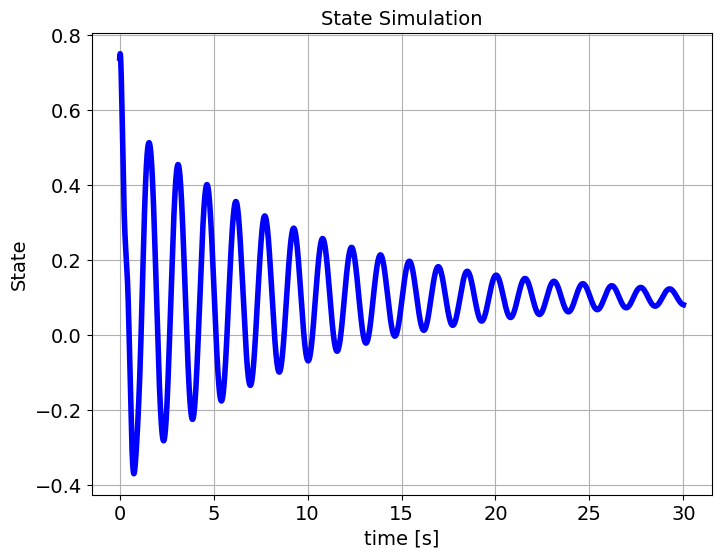

In [5]:
#                Simulate the response of the system
##########################################################################################
# Define the time vector for simulation
startTime = 0
numberSamples = 30001
h = 0.001
endTime = numberSamples * h
timeVector = np.linspace(startTime, endTime, numberSamples)

# Define the control input vector for simulation
controlInputVector = 10 * np.ones(numberSamples)

# Simulate the system
# 1st input argument - state-space model
# 2nd input argument - time vector
# 3rd input argument - defined control input
# 4th input argument - initial state for simulation
returnSimulation = ct.forced_response(sysStateSpace, timeVector, controlInputVector, x0)

# Time values of returned objects
returnSimulation.time

# Computed outputs of the system
returnSimulation.outputs

# State sequence of the system
returnSimulation.states

# Inputs used for simulation
returnSimulation.inputs

# plot the simulation results
plottingFunction(returnSimulation.time,
                 returnSimulation.states[0,:],
                 titleString='State Simulation',
                 stringXAxis='time [s]',
                 stringYAxis='State',
                 stringFileName='stateResponse1.png')

In [6]:
# Select desired observer pole locations
desiredObserverPoleLocations = [-5+1j, -5-1j, -2, -3]

# Pole placement explanation:
# Keep in mind that we send transposes of system matrices.
# This is because the place function is originally designed for control pole placement problems.
# Reference: https://python-control.readthedocs.io/en/latest/generated/control.place.html
# The function ct.place(A, B, poles) returns a matrix K such that matrix A - B*K has poles 
# at the desired locations given by "poles."

# We know that the eigenvalues of a matrix and its transpose are equal.
# We can use this fact by observing that (A - L*C)' = A' - C'*L'.
# Consequently, by using ct.place(A.T, C.T, observerPoles), where observerPoles 
# are the set of desired observer poles, we can calculate the matrix L'.

# Calculate the matrix L'
Ltranspose = ct.place(A.T, C.T, desiredObserverPoleLocations)

# Observer gain matrix
L = Ltranspose.T

# Closed-loop observer matrix
Ao = A - np.matmul(L, C)

# Double check the eigenvalues and compare the result with desiredObserverPoleLocations
computedEigenValues = np.linalg.eig(Ao)[0]

<StateSpace>: sys[4]
Inputs (2): ['u[0]', 'u[1]']
Outputs (4): ['y[0]', 'y[1]', 'y[2]', 'y[3]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[-10.33333333   1.           0.           0.        ]
     [ 33.72222222  -3.         100.           2.5       ]
     [  5.36122222   0.           0.           1.        ]
     [-20.59703704   1.66666667 -66.66666667  -1.66666667]]

B = [[   0.           10.33333333]
     [   0.         -183.72222222]
     [   0.           -5.36122222]
     [   0.33333333   87.2637037 ]]

C = [[1. 0. 0. 0.]
     [0. 1. 0. 0.]
     [0. 0. 1. 0.]
     [0. 0. 0. 1.]]

D = [[0. 0.]
     [0. 0.]
     [0. 0.]
     [0. 0.]]



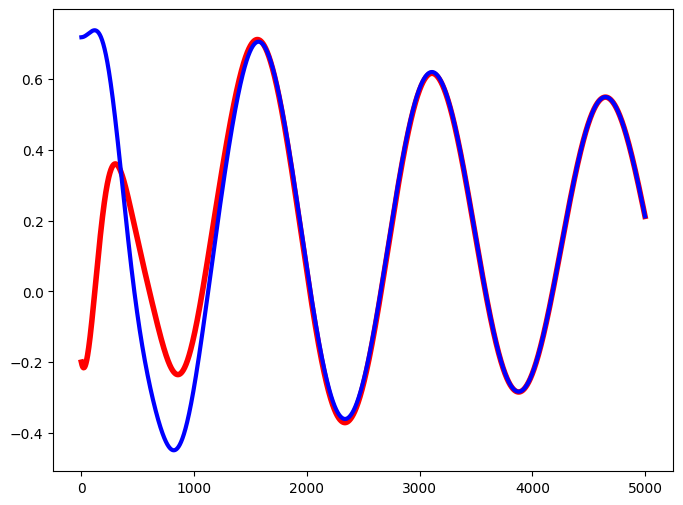

In [10]:
# Observer simulation

# Form the observer state-space model
Bo = np.column_stack((B, L))  # Stack the input and observer gain matrix
# We return as the output the complete observer state
Co = np.eye(4)  # Identity matrix to output all states
Do = np.zeros(shape=(4, 2))  # Zero matrix for the direct transmission term

# Define the observer state-space model
observerStateSpace = ct.ss(Ao, Bo, Co, Do)
print(observerStateSpace)

# This is our initial guess of the state (initial state of the observer)
x0observer = np.array([[0.4], [0.3], [-0.2], [0.2]])

# The inputs of the observer are the inputs and outputs of the original system
inputObserver = np.row_stack((returnSimulation.inputs, returnSimulation.outputs))

# Here we simulate the observer
returnSimulationObserver = ct.forced_response(observerStateSpace, 
                                              timeVector, 
                                              inputObserver, 
                                              x0observer)

# Extract the states of the observer and the system
statesObserver = returnSimulationObserver.states
statesSystem = returnSimulation.states

# Compute the estimation error time sequence
estimationError = statesSystem - statesObserver

# Plot the results
# Select the state to plot: 0,1,2,3

stateNumber = 2

plt.figure(figsize=(8,6))
plt.plot(statesObserver[stateNumber,0:5000], color='red',
         label="observed state", linewidth=4)
plt.plot(statesSystem[stateNumber,0:5000], color='blue',
         label="True state", linewidth=3)
